In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import re
import matplotlib.pyplot as plt
import multi_Layer_transformer as mlt

In [2]:
m = mlt.LLM().to(mlt.device)
optimizer = torch.optim.AdamW(m.parameters(), mlt.lr, weight_decay = 0.01)

The training loss at step 0 is 2.6888794898986816
The validation loss at step 0 is 2.8638179302215576
The training loss at step 100 is 2.6316617941856384
The validation loss at step 100 is 2.8297605514526367
The training loss at step 200 is 2.6026637029647826
The validation loss at step 200 is 2.7581472396850586
The training loss at step 300 is 2.5958522820472716
The validation loss at step 300 is 2.8887219429016113
The training loss at step 400 is 2.5637044525146484
The validation loss at step 400 is 2.728634834289551
The training loss at step 500 is 2.569565243721008
The validation loss at step 500 is 2.706878662109375
The training loss at step 600 is 2.5395197081565857
The validation loss at step 600 is 2.6644206047058105
The training loss at step 700 is 2.543711688518524
The validation loss at step 700 is 2.704822301864624
The training loss at step 800 is 2.5184003829956056
The validation loss at step 800 is 2.783568859100342
The training loss at step 900 is 2.507023420333862
The v

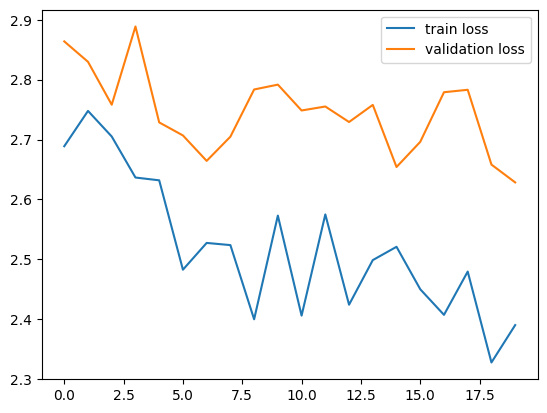

In [4]:
train_loss = []
train_loss2 = []
val_loss = []
m.train()
for _ in range(mlt.steps):
    X, Y = mlt.get_batch('train')
    logit, loss = m(X, Y)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    train_loss2.append(loss.item())
    if _%100 == 0:
        Xval, Yval = mlt.get_batch('val')
        logit, valloss = m(Xval, Yval)
        train_loss.append(loss.item())
        val_loss.append(valloss.item())
        print(f"The training loss at step {_} is {sum(train_loss2)/len(train_loss2)}")
        print(f"The validation loss at step {_} is {val_loss[-1]}")
        train_loss2 = []
plt.plot(train_loss, label = 'train loss')
plt.plot(val_loss, label = 'validation loss')
plt.legend()
plt.show()

In [5]:
inn = torch.tensor(mlt.bpe.encode('The meaning of life is'), device=mlt.device)

In [6]:
inn = inn.reshape(1,-1)

In [7]:
m.eval()
out = m.generate_n(inn, 100)

In [8]:
print(mlt.bpe.decode(out.tolist()[0]))

The meaning of life istinued with shintelurratmistellrowanigratcarreoongrustanight and and a to rueth onondevinstanokender and winvachwintonster the wininstanoicvilbustonder wilke hapitch and to rarest


In [6]:
m.eval()
answer = m.generate_n(torch.tensor([tk.encode("The meaning of life is")]).to(mlt.device),100)

In [ ]:
mlt.bpe.decode(answer.tolist()[0])

The meaning of life isthemecececesthassthanesssssthenenigrr, aniglyigrrrrr, themememenigr anigr. ousssssssssssssssss_ussss


In [20]:
answer.tolist()[0]

[7]